In [1]:
%pip install pyAgrum pandas numpy matplotlib kneed

Note: you may need to restart the kernel to use updated packages.


In [2]:
# IMPORT
from IPython.display import Image, Math

import os
import numpy as np
import pandas as pd
from utils_RAL import *
import pyAgrum
import pyAgrum.skbn as skbn
import pyAgrum.lib.notebook as gnb
import pyAgrum.lib.image as gimg
import pyAgrum.lib.dynamicBN as gdyn
import pyAgrum.causal as pyc
import pyAgrum.causal.notebook as cslnb
# from pyAgrum.lib.discretizer import Discretizer
import re
from sklearn.cluster import KMeans
# from kneed import KneeLocator
from scipy.stats import iqr, gaussian_kde, entropy
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'  # Set background to white globally
plt.rcParams['axes.facecolor'] = 'white'    # Set axis background to white
import warnings
import pickle
warnings.filterwarnings("ignore")

print(pyAgrum.__version__)

1.13.2


In [3]:
   
def find_bin(value, edges):
    """
    Given a continuous value and an array of bin edges,
    return the index of the bin that contains the value.
    """
    idx = np.digitize(value, edges, right=False) - 1
    return int(max(0, min(idx, len(edges) - 2)))


def get_info(D, auditDict, var):
    if 'param' in auditDict[var] and isinstance(auditDict[var]['param'], list):
        edges = auditDict[var]['param']
        midpoints = [(edges[i] + edges[i+1]) / 2.0 for i in range(len(edges)-1)]
        return auditDict[var]['param'], edges, midpoints
    quantiles = np.linspace(0, 100, auditDict[var]['param'] + 1 if 'param' in auditDict[var] else auditDict[var]['nbBins'] + 1)
    edges = np.percentile(D[var].values, quantiles)
    midpoints = [(edges[i] + edges[i+1]) / 2.0 for i in range(len(edges)-1)]
    return quantiles, edges, midpoints


def optimal_bins_elbow_method(time_series, min_bins=2, max_bins=15, plot=True):
    """
    Determines the optimal number of bins using the elbow method with KMeans clustering.

    Parameters:
    - time_series: numpy array or list of numerical values (1D time series)
    - min_bins: minimum number of bins to consider
    - max_bins: maximum number of bins to consider
    - plot: whether to plot the elbow curve

    Returns:
    - optimal_bins: The optimal number of bins for discretization
    """
    time_series = np.array(time_series).reshape(-1, 1)  # Ensure data is 2D for KMeans

    inertia_values = []
    bin_range = range(min_bins, max_bins + 1)

    for k in bin_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(time_series)
        inertia_values.append(kmeans.inertia_)

    # Use KneeLocator to find the elbow point
    kneedle = KneeLocator(bin_range, inertia_values, curve="convex", direction="decreasing")
    optimal_bins = kneedle.elbow

    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(bin_range, inertia_values, marker="o", linestyle="-", label="Inertia")
        plt.axvline(optimal_bins, linestyle="--", color="red", label=f"Optimal Bins: {optimal_bins}")
        plt.xlabel("Number of Bins (Clusters)")
        plt.ylabel("Inertia (WCSS)")
        plt.title("Elbow Method for Optimal Bin Selection")
        plt.legend()
        plt.grid(True)
        plt.show()

    return optimal_bins



def optimal_bins(timeseries):
    """
    Determines the optimal number of bins for a given time series using
    the Freedman-Diaconis rule and KL Divergence comparison with KDE.

    Parameters:
    - timeseries: array-like, the time series data.

    Returns:
    - best_bins: int, the optimal number of bins.
    - best_method: str, the name of the best method.
    - all_bins: dict, dictionary of bins per method.
    """
    
    # Compute data range
    N = len(timeseries)
    range_data = np.max(timeseries) - np.min(timeseries)

    # Different binning rules
    bin_methods = {
        "Sturges": int(np.log2(N) + 1),
        "Rice": int(2 * N**(1/3)),
        "Scott": int(range_data / (3.5 * np.std(timeseries) / N**(1/3))),
        "Freedman-Diaconis": int(range_data / (2 * iqr(timeseries) / N**(1/3)))
    }

    # KDE estimation for ground truth density
    kde = gaussian_kde(timeseries)
    x_vals = np.linspace(np.min(timeseries), np.max(timeseries), 1000)
    kde_vals = kde(x_vals)

    # KL Divergence evaluation
    kl_scores = {}

    for name, bins in bin_methods.items():
        hist, bin_edges = np.histogram(timeseries, bins=bins, density=True)
        
        # Convert histogram to probability density function
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        hist_interp = np.interp(x_vals, bin_centers, hist, left=0, right=0)
        
        # Compute KL Divergence (measuring difference from KDE)
        kl_div = entropy(hist_interp + 1e-8, kde_vals + 1e-8)  # Small value to prevent log(0)
        kl_scores[name] = kl_div

    # Select the best binning method (lowest KL divergence)
    best_method = min(kl_scores, key=kl_scores.get)
    print(f"Best binning method: {best_method}")
    best_bins = bin_methods[best_method]

    return best_bins

In [4]:
def loaf_D(indir, bagname):
    print(f"Loading : {bagname}")
    filename = os.path.join(indir, f"{bagname}", f"{bagname}.csv")
    df = pd.read_csv(filename)
    df = df[df['B'] != -1000]
    df = df.iloc[1:].reset_index(drop=True)  # Remove first row
    
    df = df.drop('B', axis=1)
    df = df.drop('ros_time', axis=1)

    
 
    original_names = list(df.columns)
    df.columns = [f'{v}t' for v in original_names]

    # Add lagged variable
    for v in original_names:
        df[f'{v}0'] = np.concatenate([df[f'{v}t'].values[1:], [0]])
    df = df.iloc[1:].reset_index(drop=True)  # Remove first row
    df = df.iloc[:-1].reset_index(drop=True)  # Remove last row
    return df

Loading : test-obs-01


<Axes: >

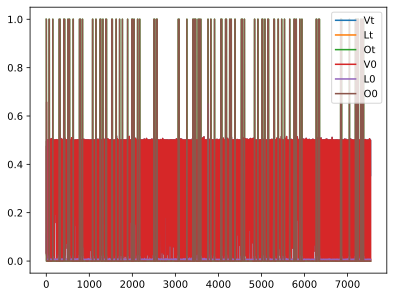

In [11]:
INDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv_pp-1-battery'
BAGNAME = 'test-obs-01'
D = loaf_D(INDIR, BAGNAME)
D.plot()

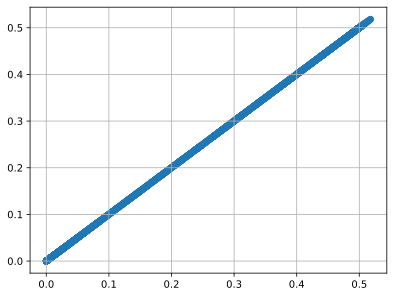

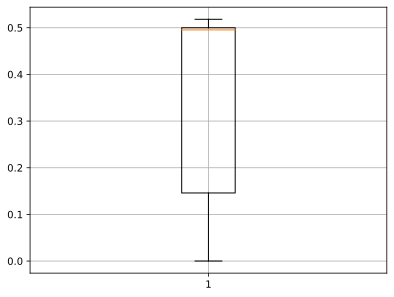

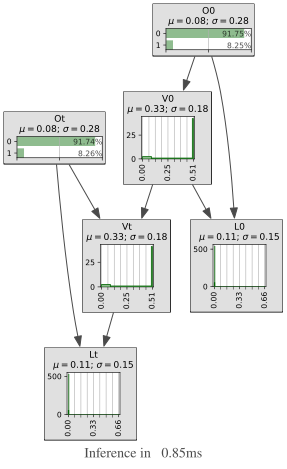

In [9]:

# DISCRETIZATION -- Compute binning once using one dataset (e.g., test_01)
discretizer=skbn.BNDiscretizer(defaultDiscretizationMethod='quantile')

# Set the same binning for all datasets
# discretizer.setDiscretizationParameters('L0', 'quantile')
# discretizer.setDiscretizationParameters('Lt', 'quantile')
# discretizer.setDiscretizationParameters('V0', 'quantile')
# discretizer.setDiscretizationParameters('Vt', 'quantile')
discretizer.setDiscretizationParameters('L0', 'quantile', 3)
discretizer.setDiscretizationParameters('Lt', 'quantile', 3)
discretizer.setDiscretizationParameters('V0', 'expert', [0, 0.088, 0.499, 0.509])
discretizer.setDiscretizationParameters('Vt', 'expert', [0, 0.088, 0.499, 0.509])

plt.scatter(D['Vt'].values, D['Vt'].values)
plt.grid(True)
plt.show()
plt.boxplot(D['Vt'].values)
plt.grid(True)
plt.show()
# Define structure
template = discretizer.discretizedBN(D)  # Use one dataset to define structure
auditDict=discretizer.audit(D)
template.addArc("O0", "L0")
template.addArc("O0", "V0")
template.addArc("V0", "L0")
template.addArc("Ot", "Vt")
template.addArc("Ot", "Lt")
template.addArc("Vt", "Lt")
template.addArc("V0", "Vt")
learner = pyAgrum.BNLearner(D, template)
learner.useSmoothingPrior()
bn = learner.learnParameters(template)
cm = pyc.CausalModel(bn)
gnb.showInference(bn)


In [10]:
target_var = 'L0'
intervention_var = "V0"

static_duration = 5
dynamic_duration = 4
charging_time = 2
LOAD_FACTOR = 5
ROBOT_MAX_VEL = 0.5
K_nl_s = 100 / (static_duration * 3600)
K_nl_d = (100 / (dynamic_duration * 3600) - K_nl_s)/(ROBOT_MAX_VEL)
K_l_s = K_nl_s * LOAD_FACTOR
K_l_d = K_nl_d * LOAD_FACTOR

print(f"Ks = {K_nl_s}")
print(f"Kd = {K_nl_d}")
print(f"Ko = {LOAD_FACTOR}")

quantiles_R_V, edges_R_V, midpoints_R_V = get_info(D, auditDict, intervention_var)
quantiles_EC, edges_EC, midpoints_EC = get_info(D, auditDict, target_var)
STEP = 1

plot_fontsize = 20

Ks = 0.005555555555555556
Kd = 0.0027777777777777766
Ko = 5


In [17]:
import json
import math
import xml.etree.ElementTree as ET

def readScenario():
    # Load and parse the XML file
    
    tree = ET.parse('/home/lcastri/git/causal-sim2real/HRISim_docker/src/pedsim_ros/pedsim_simulator/scenarios/warehouse.xml')
    root = tree.getroot()
    
    tmp = {}
    for waypoint in root.findall('waypoint'):
        waypoint_id = waypoint.get('id')
        x = float(waypoint.get('x'))
        y = float(waypoint.get('y'))
        r = float(waypoint.get('r'))
        tmp[waypoint_id] = {'x': x, 'y': y, 'r': r}
    return tmp

def pathLength(task):
    return np.sum([
        math.sqrt(
            (WPS_COORD[task['path'][wp_idx]]['x'] - WPS_COORD[task['path'][wp_idx+1]]['x'])**2 + 
            (WPS_COORD[task['path'][wp_idx]]['y'] - WPS_COORD[task['path'][wp_idx+1]]['y'])**2
        )
        for wp_idx in range(len(task['path'])-1)])

TASKDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv'
WPS_COORD = readScenario()
tod = 'H1'
S = 0.5
HZ = 1

with open(os.path.join(TASKDIR, BAGNAME, f'tasks-{tod}.json')) as pkl_file:
    TASKS = json.load(pkl_file)
TASK_IDs = list(range(TASKS['n_tasks']))
        
df = pd.read_csv(os.path.join(INDIR, BAGNAME, f"{BAGNAME}.csv"))

DTASKS = {task_id: {'path_length': 0,
                   'duration': 0,
                   'battery_consumption': 0} for task_id in TASK_IDs}
for task_id in TASK_IDs:
    
    start_time = TASKS[str(task_id)]['start']
    end_time = TASKS[str(task_id)]['end']
                
    # Filter the data for the task based on the start and end time
    task_df = df[(df['ros_time'] >= start_time) & (df['ros_time'] <= end_time)]
    
    ## path length
    DTASKS[task_id]['path_length'] = pathLength(TASKS[str(task_id)])
    
    ## battery consumption
    battery = task_df['B'].to_numpy()
    DTASKS[task_id]['battery_consumption'] = battery[0] - battery[-1]
    
    ## duration
    DTASKS[task_id]['duration'] = end_time - start_time
    
    if battery[0] - battery[-1] < -5 or battery[0] - battery[-1] == 0: 
        print(f"Removing task {task_id} with battery consumption {battery[0] - battery[-1]}")
        del DTASKS[task_id]
    
print(DTASKS)


Removing task 0 with battery consumption 0.0
Removing task 1 with battery consumption 0.0
Removing task 2 with battery consumption -1098.429557800293
{3: {'path_length': 21.447217338580614, 'duration': 58.68000000000029, 'battery_consumption': 0.48395538330079546}, 4: {'path_length': 21.447217338580614, 'duration': 69.73000000000002, 'battery_consumption': 0.49855804443359375}, 5: {'path_length': 21.447217338580614, 'duration': 52.473999999999705, 'battery_consumption': 0.34734344482420454}, 6: {'path_length': 17.849999999999998, 'duration': 57.7819999999997, 'battery_consumption': 0.36518096923830967}, 7: {'path_length': 17.85, 'duration': 14.409999999999854, 'battery_consumption': 0.18701934814448862}, 8: {'path_length': 4.0, 'duration': 26.141999999999825, 'battery_consumption': 0.30995941162110796}, 9: {'path_length': 17.85, 'duration': 45.95400000000018, 'battery_consumption': 0.30010986328130684}, 10: {'path_length': 18.89012078869655, 'duration': 65.74000000000024, 'battery_cons

In [ ]:
GT = {}
BN = {}
CM = {}
for task_id in TASK_IDs:
    
    start_time = TASKS[str(task_id)]['start']
    end_time = TASKS[str(task_id)]['end']
                
    # Filter the data for the task based on the start and end time
    task_df = df[(df['ros_time'] >= start_time) & (df['ros_time'] <= end_time)]
    PATH_LENGTH = pathLength(TASKS[str(task_id)])
    
    # GT
    battery = task_df['B'].to_numpy()
    GT[task_id] = battery[0] - battery[-1]
    
    # BN
    nsamples = PATH_LENGTH/S * HZ
    RV_bin_idx = find_bin(S, edges_R_V)
    RV_val = midpoints_R_V[RV_bin_idx]
    ie = pyAgrum.VariableElimination(bn)
    bn_prior = ie.posterior(target_var)
    evidence = {intervention_var: RV_bin_idx}
    ie.setEvidence(evidence)
    ie.makeInference()
    bn_posterior = ie.posterior(target_var)
    bn_posterior_values = bn_posterior.toarray()
    pred_bn = sum(bn_posterior_values[j] * midpoints_EC[j] for j in range(len(bn_posterior_values)))
    BN[task_id] = nsamples*pred_bn
                
    # --- CausalModel prediction ---
    formula, adj, exp = pyc.causalImpact(cm, on=target_var, doing=intervention_var, values=evidence)
    posterior_causal = adj.toarray()
    pred_causal = sum(posterior_causal[j] * midpoints_EC[j] for j in range(len(posterior_causal)))
    CM[task_id] = nsamples*pred_causal
    
gt = -sum(GT[task_id] for task_id in TASK_IDs)
bn = sum(BN[task_id] for task_id in TASK_IDs)
cm = sum(CM[task_id] for task_id in TASK_IDs)

print(f"GT: {gt}")
print(f"BN: {bn}")
print(f"CM: {cm}")